In [196]:
import numpy as np
import random
import importlib
import s331998_s330519

### Utils

In [197]:
# --- Safe Operations ---

EPS = 1e-6  # small constant to avoid divide-by-zero and overflow

# --- Primitive Set of operators ---

# Define a set of functions that can operate elementwise on numpy arrays
primitive_set = {
    'add': { 'func': np.add, 'arity': 2, 'repr': 'np.add' },
    'sub': { 'func': np.subtract, 'arity': 2, 'repr': 'np.subtract' },
    'mul': { 'func': np.multiply, 'arity': 2, 'repr': 'np.multiply' },
    'div': { 'func': np.divide, 'arity': 2, 'repr': 'np.divide' },
    'pow': { 'func': np.power, 'arity': 2, 'repr': 'np.power' },
    'abs': { 'func': np.abs, 'arity': 1, 'repr': 'np.abs' },
    'sin': { 'func': np.sin, 'arity': 1, 'repr': 'np.sin' },
    'cos': { 'func': np.cos, 'arity': 1, 'repr': 'np.cos' },
    'tan': { 'func': np.tan, 'arity': 1, 'repr': 'np.tan' },
    'exp': { 'func': np.exp, 'arity': 1, 'repr': 'np.exp' },
    'log': { 'func': np.log, 'arity': 1, 'repr': 'np.log' },
}

# We also treat the input variables as terminals. In our case, since the shape of x is (n_vars, n_samples), we refer to them by index, e.g. x[0].
terminal_set = ['x[%d]' % i for i in range(10)]  # allocate up to 10 possible variables, will use as many as needed
# Optionally, add constants as terminals:
constant_pool = [str(round(random.uniform(-100, 100), 2)) for _ in range(100)]

In [198]:
# Disable warnings from numpy about invalid operations
np.seterr(divide='ignore', invalid='ignore', over='ignore', under='ignore')

{'divide': 'ignore', 'over': 'ignore', 'under': 'ignore', 'invalid': 'ignore'}

In [199]:
import re

def update_function_in_file(func_name: str, new_expr: str, filepath="s331998_s330519.py"):
    with open(filepath, 'r') as f:
        code = f.read()

    # Build a regular expression to match the function definition
    func_pattern = rf"def {func_name}\(x: np\.ndarray\) -> np\.ndarray:\n\s+return .+"

    # Replace it with the new function
    new_func = f"def {func_name}(x: np.ndarray) -> np.ndarray:\n    return {new_expr}"
    updated_code = re.sub(func_pattern, new_func, code)

    # Write it back
    with open(filepath, 'w') as f:
        f.write(updated_code)

    print(f"Function `{func_name}` successfully updated.")

### Node Structure

In [200]:
# --- Expression Tree Structure ---

class Node:
    def __init__(self, content, children=None):
        self.content = content  # either a key for primitive_set or a terminal (variable or constant)
        self.children = children if children is not None else []

    def is_terminal(self):
        return len(self.children) == 0

    def evaluate(self, x):
        """Recursively evaluate the expression tree.
           x is expected to be a numpy array where each row is an input variable"""

        # If node is a terminal, interpret it: it's either a float constant or a variable (i.e. x[0])
        if self.is_terminal():
            # If the content is of form 'x[i]', extract the row
            if isinstance(self.content, str) and self.content.startswith('x['):  # Evaluate expression, e.g., "x[0]" returns the first row
                index = int(self.content[2:-1])
                return x[index]
            else:  # Node is a constant string, convert to float and return a numpy array of constant
                return float(self.content) * np.ones(x.shape[1])
        else:
            op = primitive_set[self.content]  # Get the function from the primitive set
            args = [child.evaluate(x) for child in self.children]  # Recursively evaluate children
            return op['func'](*args)  # Apply the operator in a vectorized way
        
    def clone(self):
        """Create a deep copy of the node and its children"""
        cloned_children = [child.clone() for child in self.children]
        return Node(self.content, cloned_children)
    
    def flatten_tree(self):
        """Return a list of all nodes in the tree."""
        nodes = [self]
        if not self.is_terminal():
            for child in self.children:
                nodes.extend(child.flatten_tree())
        return nodes

    def __str__(self):
        """Return a string representation of the expression"""
        if self.is_terminal():
            return str(self.content)
        else:
            op_repr = primitive_set[self.content]['repr']
            if primitive_set[self.content]['arity'] == 1:
                return f"{op_repr}({self.children[0]})"
            elif primitive_set[self.content]['arity'] == 2:
                return f"{op_repr}({self.children[0]}, {self.children[1]})"
            else:
                return f"{self.content}(" + ", ".join(str(child) for child in self.children) + ")"

### Evolutionary Algorithm

In [201]:
# --- Fitness Function ---

def fitness(individual: Node, x: np.ndarray, y: np.ndarray):
    """Compute the Mean Squared Error (MSE) of an individual's expression on the data.
    The MSE measures the error between the real prediction y and the value predicted by the expression
    (calculated evaluating the tree with root "individual")
    """
    try:
        y_pred = individual.evaluate(x)
        # Ensure y_pred has the same shape as y.
        if y_pred.shape != y.shape:
            return np.inf
        mse = np.mean((y - y_pred) ** 2)
        if np.isnan(mse):
            return np.inf
        return mse
    except Exception:
        return np.inf

In [202]:
# --- Generate Random Expression Trees ---

def generate_random_tree(max_depth, current_depth=0, n_vars=2):
    """Generate a random expression tree with a maximum depth"""
    if current_depth >= max_depth or (current_depth > 0 and random.random() < 0.2):
        # Terminal: either a variable (if within dimension) or a constant
        if random.random() < 0.7:
            # Choose one of the available input variables
            var_index = random.randint(0, n_vars - 1)
            return Node(f'x[{var_index}]')
        else:
            # Use a random constant from the pool
            return Node(random.choice(constant_pool))
    else:
        # Choose a random primitive operation from the set
        op_key = random.choice(list(primitive_set.keys()))
        arity = primitive_set[op_key]['arity']
        children = [generate_random_tree(max_depth, current_depth + 1, n_vars) for _ in range(arity)]
        return Node(op_key, children)

In [203]:
# --- Genetic Operators: Crossover and Mutation ---
"""
def mutate(node, max_depth, n_vars):
    #Mutate a tree node by randomly replacing a subtree
    if random.random() < 0.1:  # mutation probability at this node level
        return generate_random_tree(max_depth, n_vars=n_vars)
    if not node.is_terminal():
        new_children = [mutate(child, max_depth, n_vars) for child in node.children]
        return Node(node.content, new_children)
    return node
"""

# Mutation functions

def subtree_mutation(node, max_depth, n_vars, prob=0.1):
    """
    Perform subtree mutation on a given node. This involves replacing a subtree
    with a newly generated random subtree with a certain probability.

    Args:
        node (Node): The root node of the tree to mutate.
        max_depth (int): The maximum depth of the newly generated subtree.
        n_vars (int): The number of input variables available.
        prob (float): The probability of applying mutation at this node level.

    Returns:
        Node: The mutated tree.
    """
    if random.random() < prob:  # mutation probability at this node level
        return generate_random_tree(max_depth, n_vars=n_vars)
    if not node.is_terminal():
        # Choose a random child to mutate
        child_index = random.randint(0, len(node.children) - 1)
        node.children[child_index] = subtree_mutation(
            node.children[child_index], max_depth, n_vars, prob=prob + 0.05
        )  # Increase mutation probability for deeper levels
    return node

# Mutation: Point Mutation
def point_mutation(node, max_depth, n_vars, prob=0.1):
    """
    Perform point mutation on a given node. This involves modifying the node's content
    or its children with a certain probability.

    Args:
        node (Node): The root node of the tree to mutate.
        max_depth (int): The maximum depth of the tree.
        n_vars (int): The number of input variables available.
        prob (float): The probability of applying mutation at this node level.

    Returns:
        Node: The mutated tree.
    """
    if random.random() < prob:  # mutation probability at this node level
        # If it's a terminal, mutate it to a constant or variable
        if node.is_terminal():
            if random.random() < 0.5:
                return Node(random.choice(constant_pool))  # Mutate to a constant
            else:
                var_index = random.randint(0, n_vars - 1)
                return Node(f'x[{var_index}]')  # Mutate to a variable
        else:
            # Mutate the operation to another with the same arity
            arity = primitive_set[node.content]['arity']
            possible_ops = [key for key, value in primitive_set.items() if value['arity'] == arity]
            new_op_key = random.choice(possible_ops)
            return Node(new_op_key, node.children)  # Replace operation while keeping children
    else:
        # Recursively mutate a random child
        if not node.is_terminal():
            # Choose a random child to mutate
            child_index = random.randint(0, len(node.children) - 1)
            node.children[child_index] = point_mutation(
                node.children[child_index], max_depth, n_vars, prob=prob + 0.05
            )  # Increase mutation probability for deeper levels
    return node


def mutation(node, max_depth, n_vars):
    """Apply either subtree mutation or point mutation"""
    if random.random() < 0.5:
        return subtree_mutation(node, max_depth, n_vars)
    else:
        return point_mutation(node, max_depth, n_vars)

# TODO: Implement crossover function
def crossover(node1, node2):
    """Swap a random subtree between node1 and node2"""
    if random.random() < 0.1:
        return node2
    if not node1.is_terminal() and not node2.is_terminal():
        new_children = []
        for child in node1.children:
            # With a certain probability, replace this child with a randomly chosen subtree from node2
            if random.random() < 0.5:
                new_children.append(random.choice(node2.flatten_tree()))
            else:
                new_children.append(child)
        return Node(node1.content, new_children)
    return node1

In [204]:
# --- Parent Selection ---
def tournament_selection(population, fitness_scores, tournament_size=10):
    """ Selects parents using tournament selection method """
    selected = random.sample(list(zip(population, fitness_scores)), tournament_size)
    selected.sort(key=lambda x: x[1])  # Sort by fitness (lower is better)
    # Select the best two individuals from the tournament
    return selected[0][0], selected[1][0]  # Return the best two individuals from the tournament

def rank_selection(population, fitness_scores):
    """ Selects parents using rank selection method """
    sorted_population = sorted(zip(population, fitness_scores), key=lambda x: x[1])
    ranks = np.arange(len(population))
    probabilities = (ranks + 1) / sum(ranks + 1) # avoid division by zero
    selected_indices = np.random.choice(len(population), size=2, p=probabilities)
    return sorted_population[selected_indices[0]][0], sorted_population[selected_indices[1]][0]  # Return the best two individuals

def fitness_proportional_selection(population, fitness_scores):
    """ Selects parents using fitness proportional selection method """
    fitness_scores = np.array(fitness_scores)
    fitness_scores = 1 / (fitness_scores + EPS)  # Invert fitness scores to make them positive
    probabilities = fitness_scores / np.sum(fitness_scores)
    selected_indices = np.random.choice(len(population), size=2, p=probabilities)
    return population[selected_indices[0]], population[selected_indices[1]]  # Return the best two individuals 

def parent_selection(population, fitness_scores, method='rank'):
    """ Selects parents using the specified selection method """
    if method == 'tournament':
        return tournament_selection(population, fitness_scores)
    elif method == 'rank':
        return rank_selection(population, fitness_scores)
    elif method == 'fitness_proportional':
        return fitness_proportional_selection(population, fitness_scores)
    else:
        raise ValueError(f"Unknown selection method: {method}")

In [205]:
# --- Evolutionary Algorithm ---

def genetic_programming(x: np.ndarray, y: np.ndarray, n_vars: int, population_size=300, generations=500, elitism = 30, max_depth=10, threshold=1e-5):
    # Create an initial population of random trees
    population = [generate_random_tree(max_depth, n_vars=n_vars) for _ in range(population_size)]
    best_individual = None
    best_fitness = np.inf

    for gen in range(generations):
        fitness_values = [fitness(ind, x, y) for ind in population]  # Evaluate fitness for each individual

        # Check if we have a solution that is good enough (early stopping)
        if min(fitness_values) < threshold:
            best_fitness = min(fitness_values)
            best_individual = population[fitness_values.index(best_fitness)]
            print(f"Early stopping at generation {gen}: best fitness = {best_fitness}")
            break

        # Save the best so far
        for ind, fit in zip(population, fitness_values):
            if fit < best_fitness:
                best_fitness = fit
                best_individual = ind

        if gen % 100 == 0 or gen == generations - 1:
            print(f"Generation {gen}: best fitness = {best_fitness}")

        # Create a new population
        elite_population = sorted(zip(population, fitness_values), key=lambda x: x[1])[:elitism]
        new_population = [ind for ind, _ in elite_population]

        while len(new_population) < population_size:
            # Select parents
            parent1, parent2 = parent_selection(population, fitness_values)
            
            # Perform crossover and mutation
            if random.random() < 0.5:
                # Crossover
                child = crossover(parent1, parent2)
            else:
                # Clone one of the parents and perform mutation
                child = random.choice([parent1, parent2]).clone()
                child = mutation(child, max_depth, n_vars)

            new_population.append(child)
        
        population = new_population

    print("Best expression found:")
    print(best_individual)
    return best_individual

### Plots

In [206]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # This import registers the 3D projection


def plot_true_vs_predicted(y_true: np.ndarray, y_pred: np.ndarray):
    """ Generates a scatter plot of true vs predicted values """
    plt.figure(figsize=(8, 6))
    plt.scatter(y_true, y_pred, alpha=0.5, c='blue', edgecolors='k')
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    plt.xlabel('True Values')
    plt.ylabel('Predicted Values')
    plt.title('Predicted vs. True Values')
    plt.grid(True)
    plt.show()


def plot_3d_comparison(x: np.ndarray, y_true: np.ndarray, y_pred: np.ndarray):
    """ Generates 3D plots for the data.
    
    If the input x has two rows (variables), two 3D scatter plots are shown:
       - Left: True values
       - Right: Predicted values
       
    If x has more than two variables, the first two dimensions are used as the plane and
    the output values (y_true or y_pred) are shown in the third axis.
    """
    n_vars, n_samples = x.shape

    # When there are two input dimensions (n_vars == 2)
    if n_vars == 2:
        fig = plt.figure(figsize=(14, 6))

        # Plot True Values
        ax1 = fig.add_subplot(121, projection='3d')
        sc1 = ax1.scatter(x[0], x[1], y_true, c=y_true, cmap='viridis', alpha=0.8)
        ax1.set_title('True Values')
        ax1.set_xlabel('x[0]')
        ax1.set_ylabel('x[1]')
        ax1.set_zlabel('y')
        fig.colorbar(sc1, ax=ax1, shrink=0.5, aspect=10)

        # Plot Predicted Values
        ax2 = fig.add_subplot(122, projection='3d')
        sc2 = ax2.scatter(x[0], x[1], y_pred, c=y_pred, cmap='viridis', alpha=0.8)
        ax2.set_title('Predicted Values')
        ax2.set_xlabel('x[0]')
        ax2.set_ylabel('x[1]')
        ax2.set_zlabel('y')
        fig.colorbar(sc2, ax=ax2, shrink=0.5, aspect=10)

        plt.tight_layout()
        plt.show()

    # When there are more than two input dimensions
    elif n_vars >= 3:
        # We will use the first two dimensions for x and y axes, and then use the output values as the third axis
        fig = plt.figure(figsize=(14, 6))

        # True Values 3D scatter
        ax1 = fig.add_subplot(121, projection='3d')
        sc1 = ax1.scatter(x[0], x[1], y_true, c=y_true, cmap='coolwarm', alpha=0.8)
        ax1.set_title('True Values (using first two input dims)')
        ax1.set_xlabel('x[0]')
        ax1.set_ylabel('x[1]')
        ax1.set_zlabel('y')
        fig.colorbar(sc1, ax=ax1, shrink=0.5, aspect=10)

        # Predicted Values 3D scatter
        ax2 = fig.add_subplot(122, projection='3d')
        sc2 = ax2.scatter(x[0], x[1], y_pred, c=y_pred, cmap='coolwarm', alpha=0.8)
        ax2.set_title('Predicted Values (using first two input dims)')
        ax2.set_xlabel('x[0]')
        ax2.set_ylabel('x[1]')
        ax2.set_zlabel('y')
        fig.colorbar(sc2, ax=ax2, shrink=0.5, aspect=10)

        plt.tight_layout()
        plt.show()

    else:  # Lower-dimensional case: only one input variable
        plt.figure(figsize=(8, 5))
        plt.scatter(x[0], y_true, c='blue', label='True Values', alpha=0.6, marker='o')
        plt.scatter(x[0], y_pred, c='red', label='Predicted Values', alpha=0.6, marker='x')
        plt.xlabel('x[0]')
        plt.ylabel('y')
        plt.title('Lower-Dimensional Data: True vs. Predicted Values')
        plt.legend()
        plt.grid(True)
        plt.show()

## Main Routine

In [207]:
# --- Main Routine for Each Dataset ---

def run_symbolic_regression(dataset_path: str, population_size=100, generations=500, max_depth=5):
    data = np.load(dataset_path)
    x = data['x']  # x shape: (n_vars, n_samples)
    y = data['y']  # y shape: (n_samples,)
    n_vars = x.shape[0]
    best_tree = genetic_programming(x, y, n_vars, population_size, generations, max_depth)
    # Convert the best tree to a Python expression string
    expression_str = str(best_tree)
    return expression_str

### Function f1

In [208]:
# --- Generate Function f1 ---
dataset_file = "data/problem_1.npz"
print(f"Processing dataset 1 from {dataset_file}...")
expr = run_symbolic_regression(dataset_file, population_size=300, generations=500, max_depth=10)

print("\nGenerated function f1:")
print("def f1(x: np.ndarray) -> np.ndarray:")
print(f"    return {expr}")

Processing dataset 1 from data/problem_1.npz...
Early stopping at generation 0: best fitness = 0.0
Best expression found:
np.sin(x[0])

Generated function f1:
def f1(x: np.ndarray) -> np.ndarray:
    return np.sin(x[0])


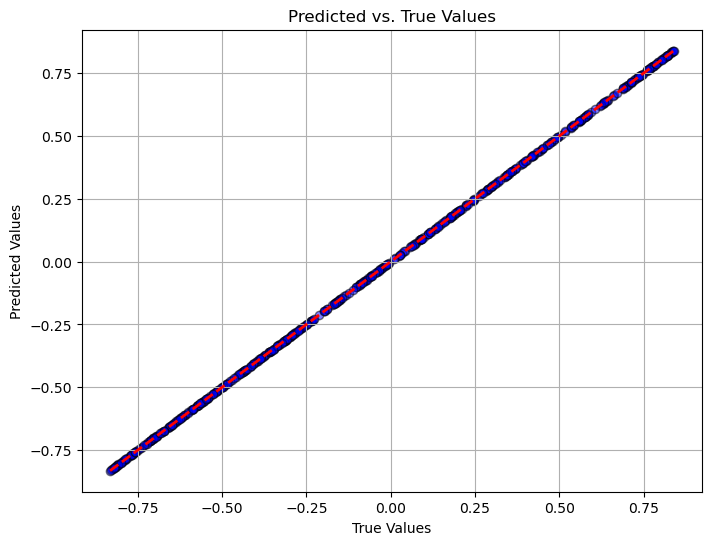

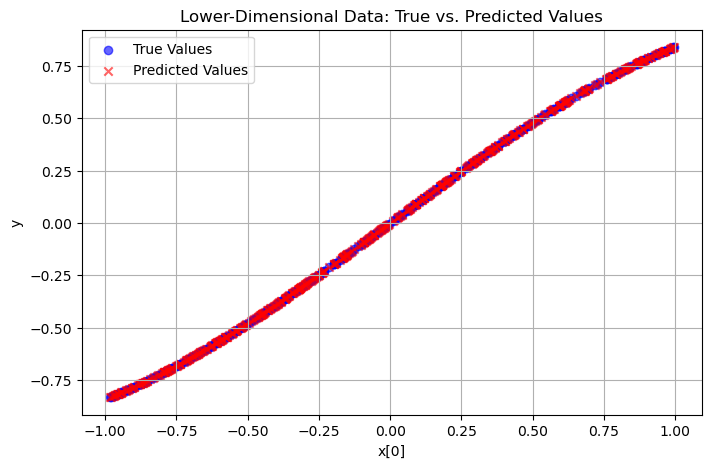

In [209]:
# --- Generate the Plots ---
importlib.reload(s331998_s330519)

data = np.load("data/problem_1.npz")
x = data['x']  # x shape: (n_vars, n_samples)
y_true = data['y']  # True outputs: shape (n_samples,)
y_pred = s331998_s330519.f1(x.copy()) # Compute predictions using the imported f1 function

plot_true_vs_predicted(y_true, y_pred) # 2D Scatter Plot: True vs. Predicted values
plot_3d_comparison(x, y_true, y_pred) # 3D Comparison Plots

### Function f2

In [210]:
# --- Generate Function f2 ---
dataset_file = "data/problem_2.npz"
print(f"Processing dataset 2 from {dataset_file}...")
expr = run_symbolic_regression(dataset_file, population_size=300, generations=1500, max_depth=10)

print("\nGenerated function f2:")
print("def f2(x: np.ndarray) -> np.ndarray:")
print(f"    return {expr}")

Processing dataset 2 from data/problem_2.npz...
Generation 0: best fitness = 29616491611105.535
Generation 100: best fitness = 28772285238200.977
Generation 200: best fitness = 28772285238200.977
Generation 300: best fitness = 28772285238200.977
Generation 400: best fitness = 28772285238200.977
Generation 500: best fitness = 28772285238200.977
Generation 600: best fitness = 28772285238200.977
Generation 700: best fitness = 28772285238200.977
Generation 800: best fitness = 28772285238200.977
Generation 900: best fitness = 28772285238200.977
Generation 1000: best fitness = 28772285238200.977
Generation 1100: best fitness = 28772285238200.977
Generation 1200: best fitness = 28606090221616.85
Generation 1300: best fitness = 28606090221616.85
Generation 1400: best fitness = 28606090221616.85
Generation 1499: best fitness = 28606090221616.85
Best expression found:
np.power(np.exp(np.log(np.subtract(np.subtract(26.87, x[0]), np.subtract(x[1], np.sin(x[1]))))), x[0])

Generated function f2:
de

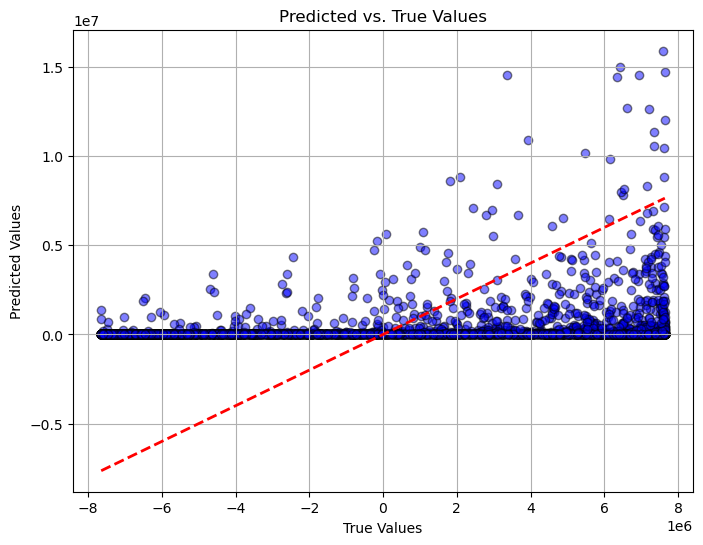

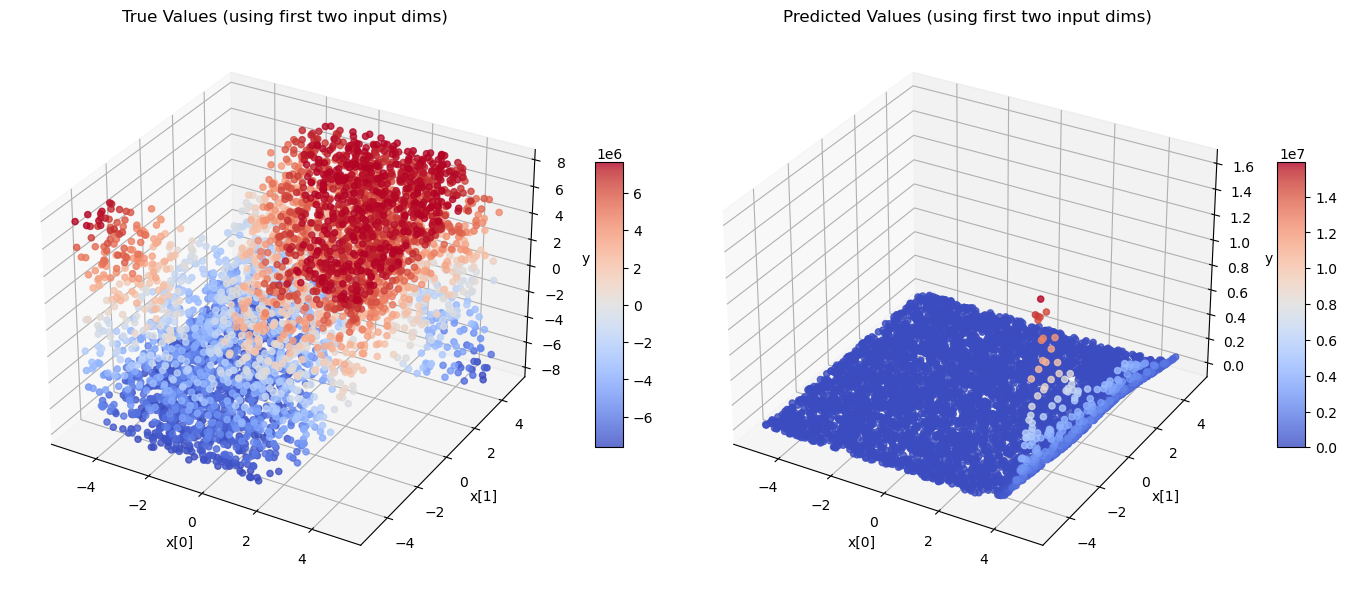

In [214]:
# --- Generate the Plots ---
importlib.reload(s331998_s330519)

data = np.load("data/problem_2.npz")
x = data['x']  # x shape: (n_vars, n_samples)
y_true = data['y']  # True outputs: shape (n_samples,)
y_pred = s331998_s330519.f2(x.copy()) # Compute predictions using the imported function

plot_true_vs_predicted(y_true, y_pred) # 2D Scatter Plot: True vs. Predicted values
plot_3d_comparison(x, y_true, y_pred) # 3D Comparison Plots

### Function f3

In [216]:
# --- Generate Function f3 ---
dataset_file = "data/problem_3.npz"
print(f"Processing dataset 3 from {dataset_file}...")
expr = run_symbolic_regression(dataset_file, population_size=300, generations=1500, max_depth=10)

print("Generated function f3:")
print("def f3(x: np.ndarray) -> np.ndarray:")
print(f"    return {expr}")

Processing dataset 3 from data/problem_3.npz...
Generation 0: best fitness = 2563.718462783475
Generation 100: best fitness = 1961.330452742634
Generation 200: best fitness = 1961.330452742634
Generation 300: best fitness = 1273.766004853436
Generation 400: best fitness = 806.4005212867423
Generation 500: best fitness = 806.4005212867423
Generation 600: best fitness = 806.4005212867423
Generation 700: best fitness = 806.4005212867423
Generation 800: best fitness = 806.4005212867423
Generation 900: best fitness = 806.4005212867423
Generation 1000: best fitness = 806.4005212867423
Generation 1100: best fitness = 806.4005212867423
Generation 1200: best fitness = 806.4005212867423
Generation 1300: best fitness = 806.4005212867423
Generation 1400: best fitness = 806.4005212867423
Generation 1499: best fitness = 806.4005212867423
Best expression found:
np.multiply(np.divide(np.abs(x[1]), np.sin(34.82)), x[1])
Generated function f3:
def f3(x: np.ndarray) -> np.ndarray:
    return np.multiply(

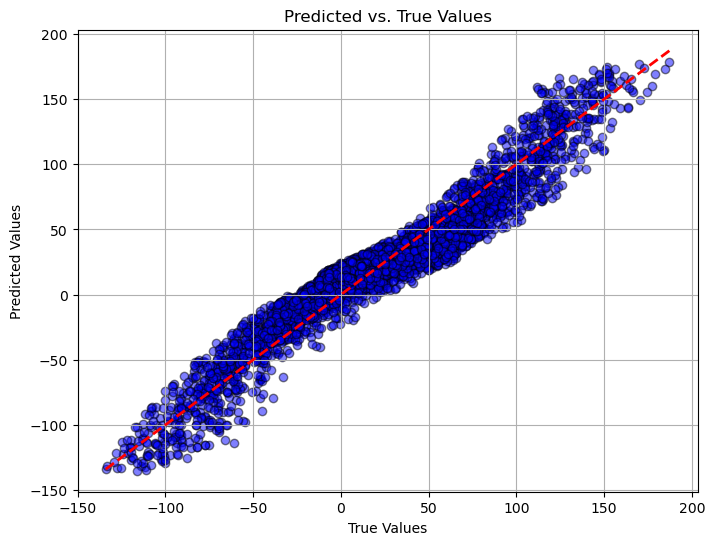

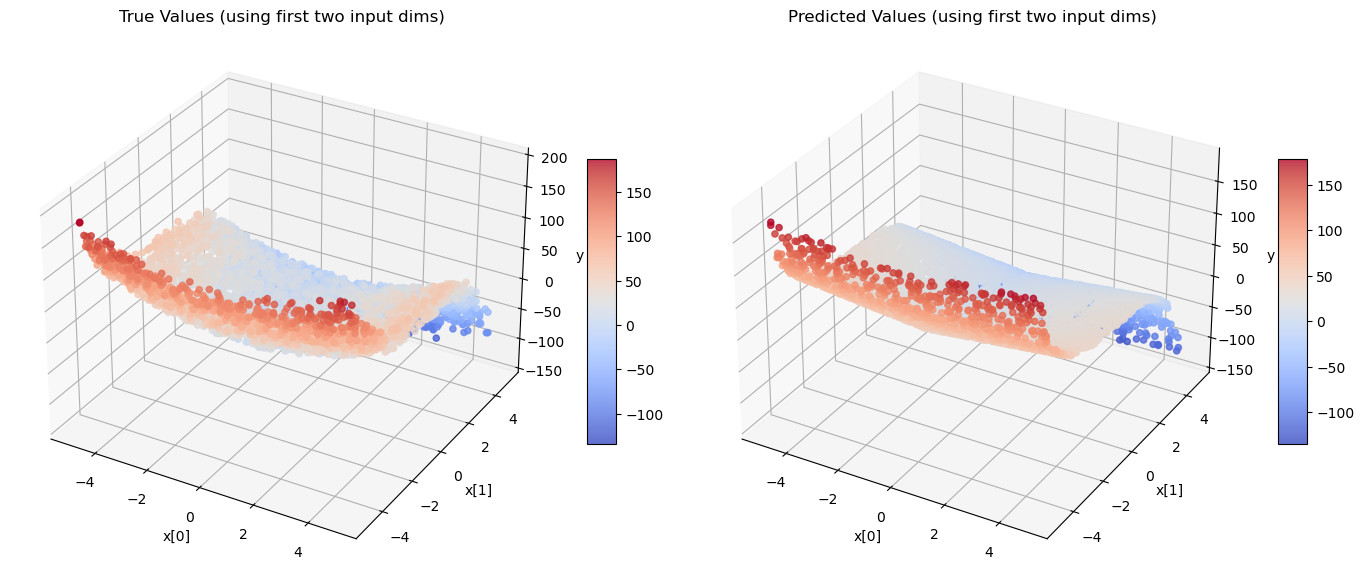

In [222]:
# --- Generate the Plots ---
importlib.reload(s331998_s330519)

data = np.load("data/problem_3.npz")
x = data['x']  # x shape: (n_vars, n_samples)
y_true = data['y']  # True outputs: shape (n_samples,)
y_pred = s331998_s330519.f3(x.copy()) # Compute predictions using the imported function

plot_true_vs_predicted(y_true, y_pred) # 2D Scatter Plot: True vs. Predicted values
plot_3d_comparison(x, y_true, y_pred) # 3D Comparison Plots

### Function f4

In [221]:
# --- Generate Function f4 ---
dataset_file = "data/problem_4.npz"
print(f"Processing dataset 4 from {dataset_file}...")
expr = run_symbolic_regression(dataset_file, population_size=200, generations=1500, max_depth=5)

print("Generated function f4:")
print("def f4(x: np.ndarray) -> np.ndarray:")
print(f"    return {expr}")

Processing dataset 4 from data/problem_4.npz...
Generation 0: best fitness = 20.766464619891348
Generation 100: best fitness = 18.784979895896814
Generation 200: best fitness = 7.908879825922346
Generation 300: best fitness = 7.908879825922346
Generation 400: best fitness = 7.908879825922346
Generation 500: best fitness = 7.908879825922346
Generation 600: best fitness = 7.908879825922346
Generation 700: best fitness = 6.671883268333337
Generation 800: best fitness = 6.671883268333337
Generation 900: best fitness = 6.671883268333337
Generation 1000: best fitness = 6.671883268333337
Generation 1100: best fitness = 6.671883268333337
Generation 1200: best fitness = 6.671883268333337
Generation 1300: best fitness = 6.671883268333337
Generation 1400: best fitness = 6.671883268333337
Generation 1499: best fitness = 6.671883268333337
Best expression found:
np.multiply(np.cos(x[1]), np.exp(np.exp(np.cos(x[1]))))
Generated function f4:
def f4(x: np.ndarray) -> np.ndarray:
    return np.multiply(

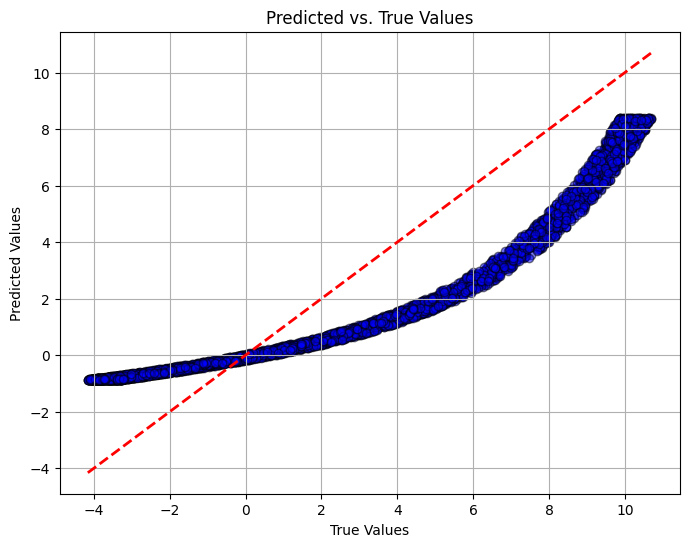

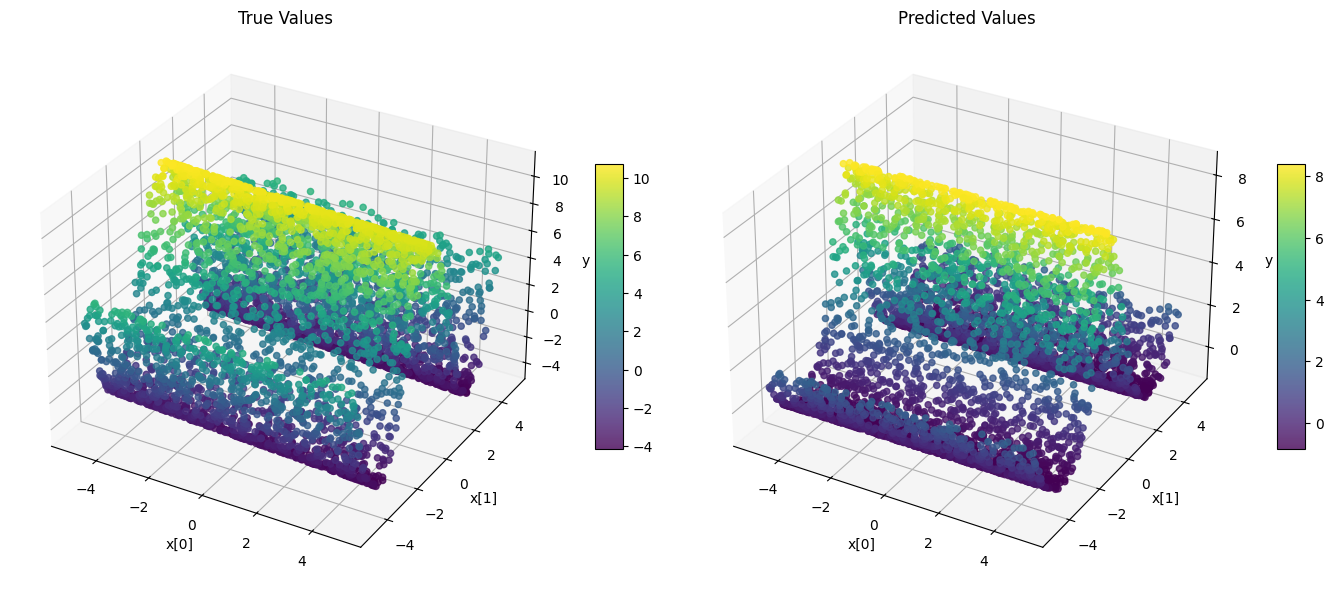

In [ ]:
# --- Generate the Plots ---
importlib.reload(s331998_s330519)

data = np.load("data/problem_4.npz")
x = data['x']  # x shape: (n_vars, n_samples)
y_true = data['y']  # True outputs: shape (n_samples,)
y_pred = s331998_s330519.f4(x.copy()) # Compute predictions using the imported function

plot_true_vs_predicted(y_true, y_pred) # 2D Scatter Plot: True vs. Predicted values
plot_3d_comparison(x, y_true, y_pred) # 3D Comparison Plots

### Function f5

In [224]:
# --- Generate Function f5 ---
dataset_file = "data/problem_5.npz"
print(f"Processing dataset 5 from {dataset_file}...")
expr = run_symbolic_regression(dataset_file, population_size=100, generations=500, max_depth=5)

print("Generated function f5:")
print("def f5(x: np.ndarray) -> np.ndarray:")
print(f"    return {expr}")

Processing dataset 5 from data/problem_5.npz...
Early stopping at generation 0: best fitness = 5.572810232617333e-18
Best expression found:
np.power(np.abs(np.cos(np.sin(np.sin(np.sin(np.sin(np.abs(np.abs(x[0])))))))), np.abs(np.subtract(np.cos(np.multiply(np.divide(np.tan(x[1]), np.add(np.add(np.exp(np.divide(x[1], x[0])), np.abs(np.cos(x[1]))), np.abs(np.divide(np.tan(x[0]), np.multiply(x[0], x[1]))))), np.tan(x[0]))), np.multiply(np.multiply(np.cos(x[0]), np.add(np.abs(np.exp(np.exp(np.log(34.82)))), x[1])), x[1]))))
Generated function f5:
def f5(x: np.ndarray) -> np.ndarray:
    return np.power(np.abs(np.cos(np.sin(np.sin(np.sin(np.sin(np.abs(np.abs(x[0])))))))), np.abs(np.subtract(np.cos(np.multiply(np.divide(np.tan(x[1]), np.add(np.add(np.exp(np.divide(x[1], x[0])), np.abs(np.cos(x[1]))), np.abs(np.divide(np.tan(x[0]), np.multiply(x[0], x[1]))))), np.tan(x[0]))), np.multiply(np.multiply(np.cos(x[0]), np.add(np.abs(np.exp(np.exp(np.log(34.82)))), x[1])), x[1]))))


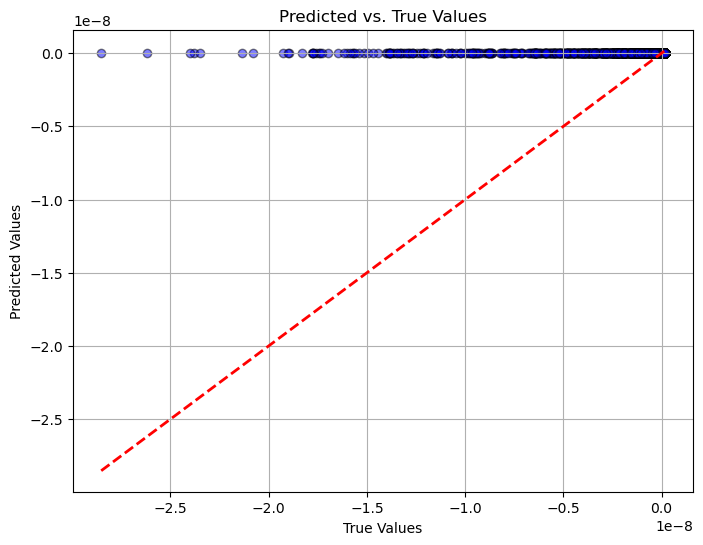

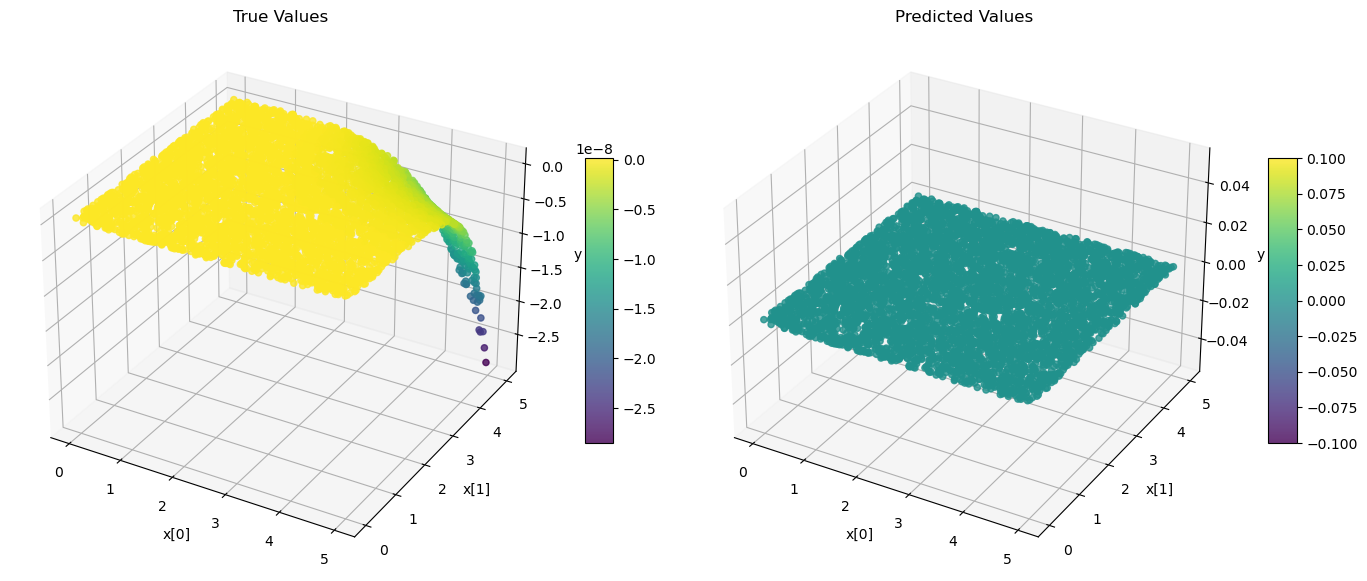

In [226]:
# --- Generate the Plots ---
importlib.reload(s331998_s330519)

data = np.load("data/problem_5.npz")
x = data['x']  # x shape: (n_vars, n_samples)
y_true = data['y']  # True outputs: shape (n_samples,)
y_pred = s331998_s330519.f5(x.copy()) # Compute predictions using the imported function

plot_true_vs_predicted(y_true, y_pred) # 2D Scatter Plot: True vs. Predicted values
plot_3d_comparison(x, y_true, y_pred) # 3D Comparison Plots

### Function f6

In [ ]:
# --- Generate Function f6 ---
dataset_file = "data/problem_6.npz"
print(f"Processing dataset 6 from {dataset_file}...")
expr = run_symbolic_regression(dataset_file, population_size=100, generations=1000, max_depth=8)

print("Generated function f6:")
print("def f6(x: np.ndarray) -> np.ndarray:")
print(f"    return {expr}")

Processing dataset 6 from data/problem_6.npz...
Generation 0: best fitness = 18.114399140392955
Generation 100: best fitness = 13.649341108704428
Generation 200: best fitness = 13.649341108704428
Generation 300: best fitness = 13.649341108704428
Generation 400: best fitness = 13.649341108704428
Generation 500: best fitness = 13.649341108704428
Generation 600: best fitness = 13.649341108704428
Generation 700: best fitness = 13.649341108704428
Generation 800: best fitness = 13.649341108704428
Generation 900: best fitness = 13.649341108704428
Generation 999: best fitness = 13.649341108704428
Best expression found:
np.add(-3.49, np.subtract(x[1], np.tan(x[1])))
Generated function f6:
def f6(x: np.ndarray) -> np.ndarray:
    return np.add(-3.49, np.subtract(x[1], np.tan(x[1])))


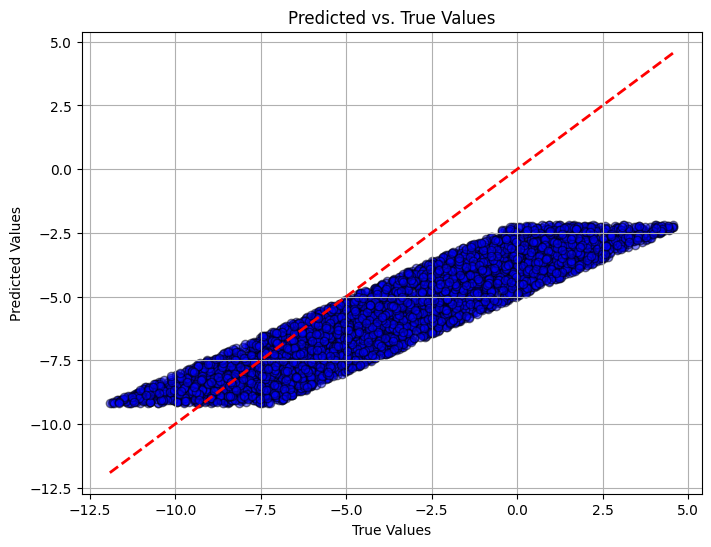

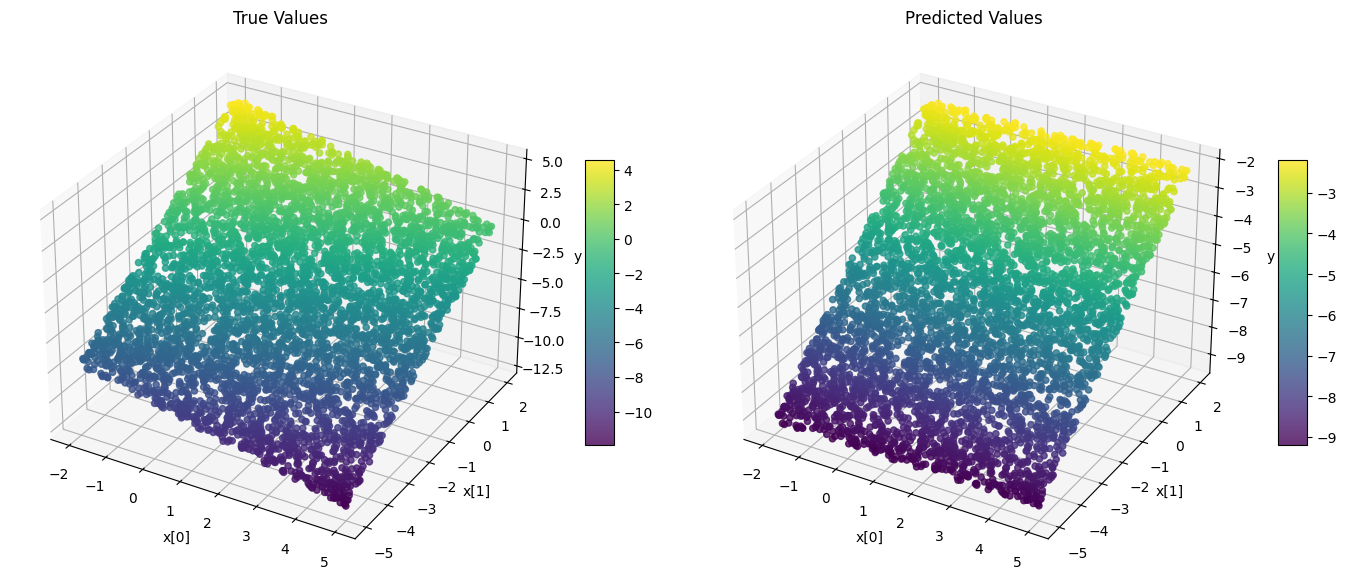

In [ ]:
# --- Generate the Plots ---
importlib.reload(s331998_s330519)

data = np.load("data/problem_6.npz")
x = data['x']  # x shape: (n_vars, n_samples)
y_true = data['y']  # True outputs: shape (n_samples,)
y_pred = s331998_s330519.f6(x.copy()) # Compute predictions using the imported function

plot_true_vs_predicted(y_true, y_pred) # 2D Scatter Plot: True vs. Predicted values
plot_3d_comparison(x, y_true, y_pred) # 3D Comparison Plots

### Function f7

In [ ]:
# --- Generate Function f7 ---
dataset_file = "data/problem_7.npz"
print(f"Processing dataset 7 from {dataset_file}...")
expr = run_symbolic_regression(dataset_file, population_size=100, generations=500, max_depth=5)

print("Generated function f7:")
print("def f7(x: np.ndarray) -> np.ndarray:")
print(f"    return {expr}")

Processing dataset 7 from data/problem_7.npz...
Generation 0: best fitness = 724.4674480652806
Generation 100: best fitness = 711.1563343205631
Generation 200: best fitness = 711.1563343205631
Generation 300: best fitness = 711.1563343205631
Generation 400: best fitness = 711.1563343205631
Generation 499: best fitness = 711.1561677668936
Best expression found:
np.add(np.log(np.divide(np.subtract(np.tan(x[1]), np.subtract(-1.33, x[0])), 0.62)), np.tan(-4.84))
Generated function f7:
def f7(x: np.ndarray) -> np.ndarray:
    return np.add(np.log(np.divide(np.subtract(np.tan(x[1]), np.subtract(-1.33, x[0])), 0.62)), np.tan(-4.84))


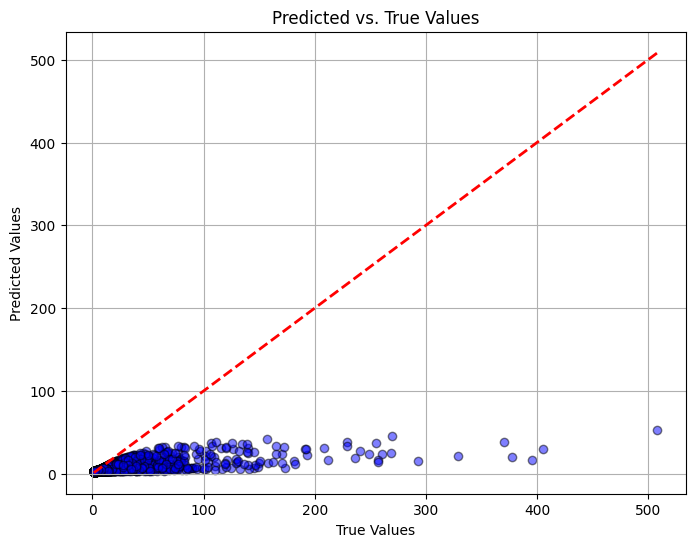

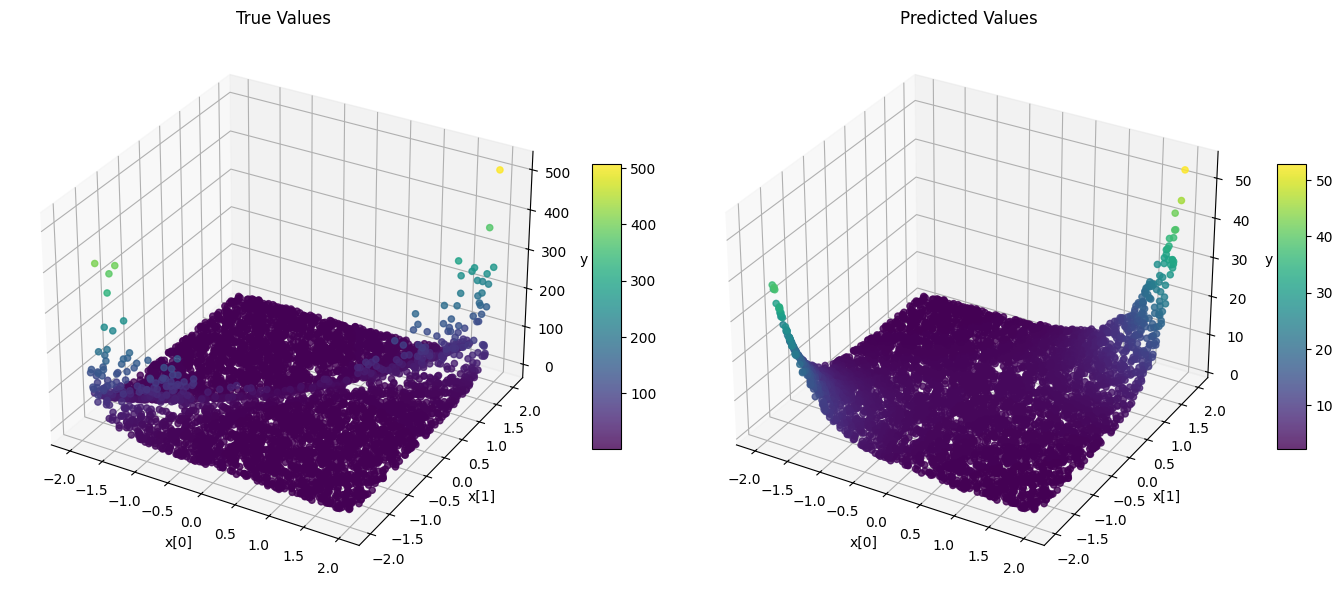

In [ ]:
# --- Generate the Plots ---
importlib.reload(s331998_s330519)

data = np.load("data/problem_7.npz")
x = data['x']  # x shape: (n_vars, n_samples)
y_true = data['y']  # True outputs: shape (n_samples,)
y_pred = s331998_s330519.f7(x.copy()) # Compute predictions using the imported function

plot_true_vs_predicted(y_true, y_pred)  # 2D Scatter Plot: True vs. Predicted values
plot_3d_comparison(x, y_true, y_pred) # 3D Comparison Plots

### Function f8

In [ ]:
# --- Generate Function f8 ---
dataset_file = "data/problem_8.npz"
print(f"Processing dataset 8 from {dataset_file}...")
expr = run_symbolic_regression(dataset_file, population_size=100, generations=500, max_depth=5)

print("Generated function f8:")
print("def f8(x: np.ndarray) -> np.ndarray:")
print(f"    return {expr}")

Processing dataset 8 from data/problem_8.npz...
Generation 0: best fitness = 23005539.796351627
Generation 100: best fitness = 22706855.479548253
Generation 200: best fitness = 22706545.1246827
Generation 300: best fitness = 22706545.1246827
Generation 400: best fitness = 22706545.1246827
Generation 499: best fitness = 22705941.856815245
Best expression found:
np.subtract(np.add(np.subtract(np.exp(np.cos(x[5])), np.exp(np.multiply(x[3], x[2]))), np.divide(x[0], x[4])), -4.84)
Generated function f8:
def f8(x: np.ndarray) -> np.ndarray:
    return np.subtract(np.add(np.subtract(np.exp(np.cos(x[5])), np.exp(np.multiply(x[3], x[2]))), np.divide(x[0], x[4])), -4.84)


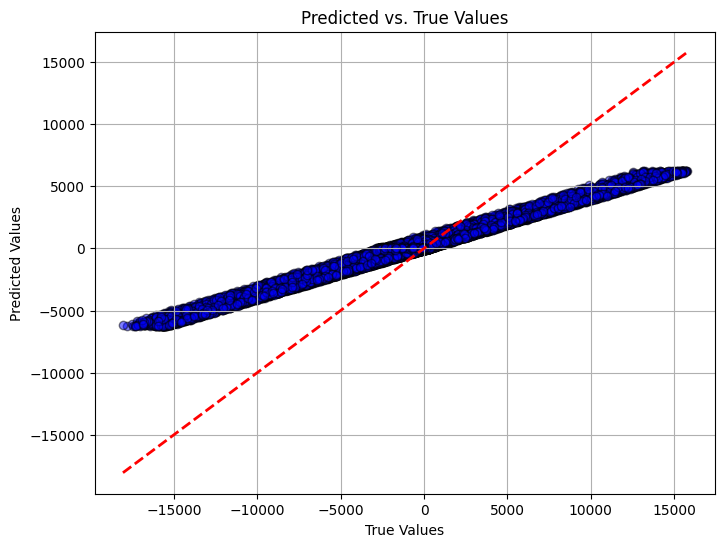

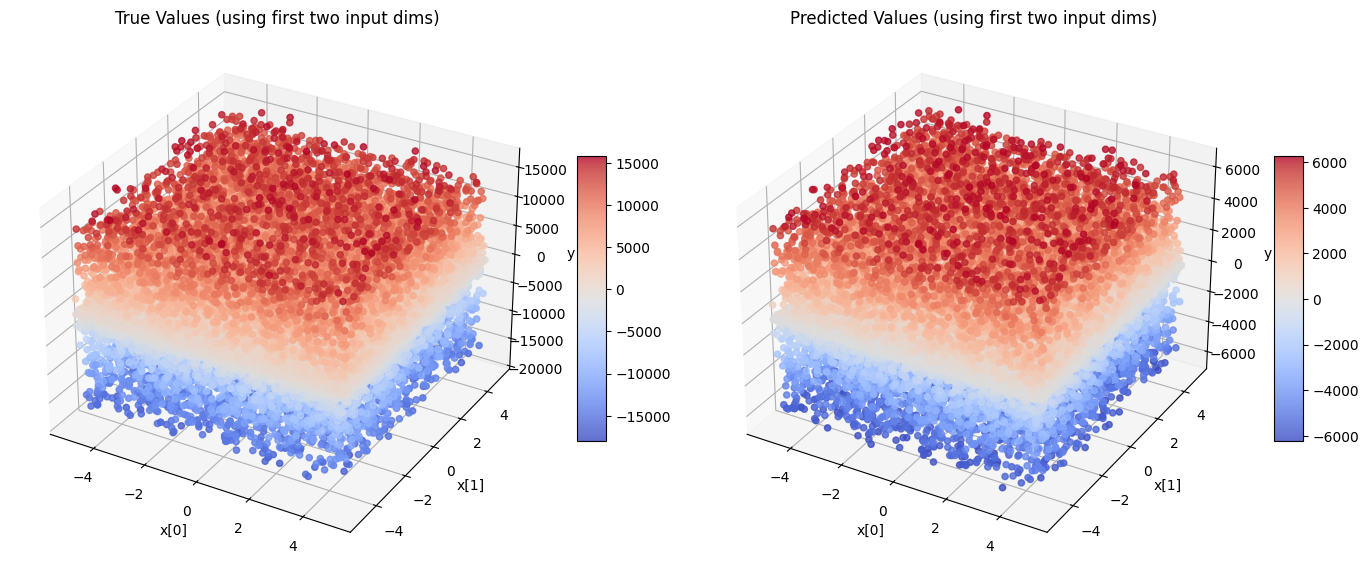

In [ ]:
# --- Generate the Plots ---
importlib.reload(s331998_s330519)

data = np.load("data/problem_8.npz")
x = data['x']  # x shape: (n_vars, n_samples)
y_true = data['y']  # True outputs: shape (n_samples,)
y_pred = s331998_s330519.f8(x.copy()) # Compute predictions using the imported function

plot_true_vs_predicted(y_true, y_pred) # 2D Scatter Plot: True vs. Predicted values
plot_3d_comparison(x, y_true, y_pred) # 3D Comparison Plots